# CURC VIIRS SNPP Workflow Planning

This notebook illustrates the CURC-specific workflow layer as a thin interactive front end over `workflows/curc`.

The intended user model is:
- choose a sensor, platform, tile, and water year,
- inspect discovered inputs and planned workflow steps,
- run one step at a time or eventually submit distributed Slurm jobs.

For this example, the source reflectance tree is the real SNPP `VNP09GA` archive on `/pl/active/rittger_ops/vnp09ga.002`.

In [2]:
from __future__ import annotations

from dataclasses import asdict
import json
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "spires").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"repo_root={REPO_ROOT}")

from spires.sensors.registry import list_supported_sensor_platforms
from workflows.curc.config import CurcWorkflowConfig
from workflows.curc.discovery import discover_viirs_snpp_water_year_reflectance_files
from workflows.curc.paths import ancillary_dir, log_root, output_date_root, reflectance_dir, r0_dir
from workflows.curc.runner import plan_viirs_snpp_steps


repo_root=/projects/ropa5718/SpiPy


## Configuration

The notebook should not define separate workflow logic, but it should expose the user-editable parameters clearly. This cell mirrors what a future external config file will contain.

In [2]:
supported = list_supported_sensor_platforms()
print(json.dumps(supported, indent=2))
print()

# User-editable workflow parameters.
SCRATCH_ROOT = Path("/scratch/alpine/ropa5718/spipy")
INPUT_SOURCE_ROOT = Path("/pl/active/rittger_ops/vnp09ga.002")
SENSOR = "viirs"
PLATFORMS = ("snpp",)
TILES = ("h08v05",)
WATER_YEARS = (2023,)
DATES = ()
DATE_GLOB = "*"
DRY_RUN = True
APPLY_VALID_INVERSION_MASK = False

config = CurcWorkflowConfig(
    scratch_root=SCRATCH_ROOT,
    input_source_root=INPUT_SOURCE_ROOT,
    sensor=SENSOR,
    platforms=PLATFORMS,
    tiles=TILES,
    years=(),
    water_years=WATER_YEARS,
    dates=DATES,
    date_glob=DATE_GLOB,
    dry_run=DRY_RUN,
    apply_valid_inversion_mask=APPLY_VALID_INVERSION_MASK,
).canonicalized()

config


{
  "modis": [
    "terra",
    "aqua"
  ],
  "viirs": [
    "snpp",
    "noaa20",
    "noaa21"
  ]
}



CurcWorkflowConfig(scratch_root=PosixPath('/scratch/alpine/ropa5718/spipy'), input_source_root=PosixPath('/pl/active/rittger_ops/vnp09ga.002'), sensor='viirs', platforms=('snpp',), tiles=('h08v05',), years=(), water_years=(2023,), dates=(), date_glob='*', dry_run=True, max_auto_retry_count=3, slurm_profile=SlurmProfile(account=None, qos=None, time=None, mem=None, cpus_per_task=None, output_dir=None, extra_args=()))

## Scratch Layout

The CURC workflow keeps shared staged inputs under `/scratch/alpine/.../input` and dated inversion outputs under `/scratch/alpine/.../output`.

In [3]:
platform = config.platforms[0]
tile = config.tiles[0]
water_year = config.water_years[0]

print("reflectance:", reflectance_dir(config, platform) / tile / str(water_year))
print("ancillary:", ancillary_dir(config, platform) / tile)
print("r0:", r0_dir(config, platform) / tile / str(water_year))
print("output_date:", output_date_root(config, platform, tile, "2023-03-16"))
print("logs:", log_root(config) / config.sensor / platform / tile / str(water_year))


reflectance: /scratch/alpine/ropa5718/spipy/input/viirs/snpp/reflectance/h08v05/2023
ancillary: /scratch/alpine/ropa5718/spipy/input/viirs/snpp/ancillary/h08v05
r0: /scratch/alpine/ropa5718/spipy/input/viirs/snpp/ancillary/r0/h08v05/2023
output_date: /scratch/alpine/ropa5718/spipy/output/viirs/snpp/h08v05/2023-03-16
logs: /scratch/alpine/ropa5718/spipy/logs/viirs/snpp/h08v05/2023


## Full Water-Year Discovery

This discovery step is the first concrete replacement for the opaque batch bash scripts. It gives a direct view of which source files are available for one tile and one water year.

In [4]:
reflectance_files = discover_viirs_snpp_water_year_reflectance_files(
    config,
    tile=tile,
    water_year=water_year,
)

print("water_year_file_count", len(reflectance_files))
print("first_file", reflectance_files[0] if reflectance_files else None)
print("last_file", reflectance_files[-1] if reflectance_files else None)


water_year_file_count 364
first_file /pl/active/rittger_ops/vnp09ga.002/input/h08v05/2022/VNP09GA.A2022274.h08v05.002.2023067084622.h5
last_file /pl/active/rittger_ops/vnp09ga.002/input/h08v05/2023/VNP09GA.A2023273.h08v05.002.2023276002621.h5


## Full Water-Year Step Plan

The workflow should be step-oriented rather than all-or-nothing. For a full water year, the planner expands the request into the major steps that will later become executable or submitted jobs.

In [5]:
full_water_year_steps = plan_viirs_snpp_steps(
    config,
    tile=tile,
    water_year=water_year,
)

for step in full_water_year_steps:
    summary = {
        "step": step.step,
        "date_count": step.date_count,
        "destination_path": step.destination_path,
        "r0_year": step.r0_year,
    }
    print(json.dumps(summary, indent=2))


{
  "step": "stage_reflectance",
  "date_count": 364,
  "destination_path": "/scratch/alpine/ropa5718/spipy/input/viirs/snpp/reflectance/h08v05/2023",
  "r0_year": null
}
{
  "step": "stage_ancillary",
  "date_count": 364,
  "destination_path": "/scratch/alpine/ropa5718/spipy/input/viirs/snpp/ancillary/h08v05",
  "r0_year": null
}
{
  "step": "build_r0",
  "date_count": 106,
  "destination_path": "/scratch/alpine/ropa5718/spipy/input/viirs/snpp/ancillary/r0/h08v05/2022",
  "r0_year": 2022
}
{
  "step": "run_inversion",
  "date_count": 364,
  "destination_path": "/scratch/alpine/ropa5718/spipy/output/viirs/snpp/h08v05",
  "r0_year": 2022
}


## Single-Date Rerun Plan

A key design goal is that a user can rerun a single date without relaunching the entire water year. This is the concrete planning path for that case.

In [6]:
single_date = "2023-03-16"

single_date_steps = plan_viirs_snpp_steps(
    config,
    tile=tile,
    water_year=water_year,
    target_dates=(single_date,),
)

for step in single_date_steps:
    print(json.dumps(asdict(step), indent=2))


{
  "step": "stage_reflectance",
  "sensor": "viirs",
  "platform": "snpp",
  "tile": "h08v05",
  "water_year": 2023,
  "date_count": 1,
  "dates": [
    "2023-03-16"
  ],
  "source_paths": [
    "/pl/active/rittger_ops/vnp09ga.002/input/h08v05/2023/VNP09GA.A2023075.h08v05.002.2023101231908.h5"
  ],
  "destination_path": "/scratch/alpine/ropa5718/spipy/input/viirs/snpp/reflectance/h08v05/2023",
  "notes": [
    "Copy or rsync the discovered VNP09GA files from /pl to /scratch/alpine.",
    "This step can target a full water year or a single acquisition date."
  ],
  "r0_year": null
}
{
  "step": "stage_ancillary",
  "sensor": "viirs",
  "platform": "snpp",
  "tile": "h08v05",
  "water_year": 2023,
  "date_count": 1,
  "dates": [
    "2023-03-16"
  ],
  "source_paths": [],
  "destination_path": "/scratch/alpine/ropa5718/spipy/input/viirs/snpp/ancillary/h08v05",
  "notes": [
    "Ensure static ancillary inputs such as canopy, terrain, landcover, and water masks are staged.",
    "This is 

## Development Direction

The next implementation steps are not notebook-specific. They belong in `workflows/curc` and should later be callable from notebooks, scripts, and Slurm entrypoints:
- execute `stage_reflectance` as an explicit rsync/copy operation,
- execute `stage_ancillary` with clear checks for static tile inputs,
- implement summer-only source selection for `build_r0`,
- run inversion per date or per chunk while preserving the same step boundaries.

## Step Execution Helpers

Preview direct staging and R0 execution from the current CURC workflow helpers. These steps run outside Slurm; `run_inversion` still uses the manifest-backed array submission flow.


In [10]:
from workflows.curc.runner import preview_viirs_snpp_step_execution, run_viirs_snpp_step

target_dates = (single_date,)

for step_name in ("stage_reflectance", "stage_ancillary", "build_r0"):
    payload = preview_viirs_snpp_step_execution(
        config,
        tile=tile,
        water_year=water_year,
        step=step_name,
        target_dates=target_dates,
    )
    print(f"\n[{step_name}]")
    print(json.dumps(payload, indent=2))



[stage_reflectance]
{
  "step": "stage_reflectance",
  "sensor": "viirs",
  "platform": "snpp",
  "tile": "h08v05",
  "water_year": 2023,
  "date_count": 1,
  "dates": [
    "2023-03-16"
  ],
  "source_path_count": 1,
  "source_paths": [
    "/pl/active/rittger_ops/vnp09ga.002/input/h08v05/2023/VNP09GA.A2023075.h08v05.002.2023101231908.h5"
  ],
  "destination_path": "/gpfs/alpine1/scratch/ropa5718/spipy/input/viirs/snpp/reflectance/h08v05/2023",
  "notes": [
    "Copy or rsync the discovered VNP09GA files from /pl to /scratch/alpine.",
    "This step can target a full water year or a single acquisition date."
  ],
  "r0_year": null,
  "overwrite": false,
  "mode": "direct_rsync",
  "commands": [
    [
      "rsync",
      "-av",
      "--ignore-existing",
      "/pl/active/rittger_ops/vnp09ga.002/input/h08v05/2023/VNP09GA.A2023075.h08v05.002.2023101231908.h5",
      "/gpfs/alpine1/scratch/ropa5718/spipy/input/viirs/snpp/reflectance/h08v05/2023/"
    ]
  ],
  "shell_commands": [
    "r

In [16]:
# Set EXECUTE_STEP = True only when you want to perform the filesystem or R0 action.
EXECUTE_STEP = True
STEP_NAME = "build_r0"

result = run_viirs_snpp_step(
    config,
    tile=tile,
    water_year=water_year,
    step=STEP_NAME,
    target_dates=target_dates,
    execute=EXECUTE_STEP,
    overwrite=False,
    show_progress=True,
)
print(json.dumps(result, indent=2))


Building VIIRS R0:   0%|          | 0/106 [00:00<?, ?it/s]

KeyboardInterrupt: 

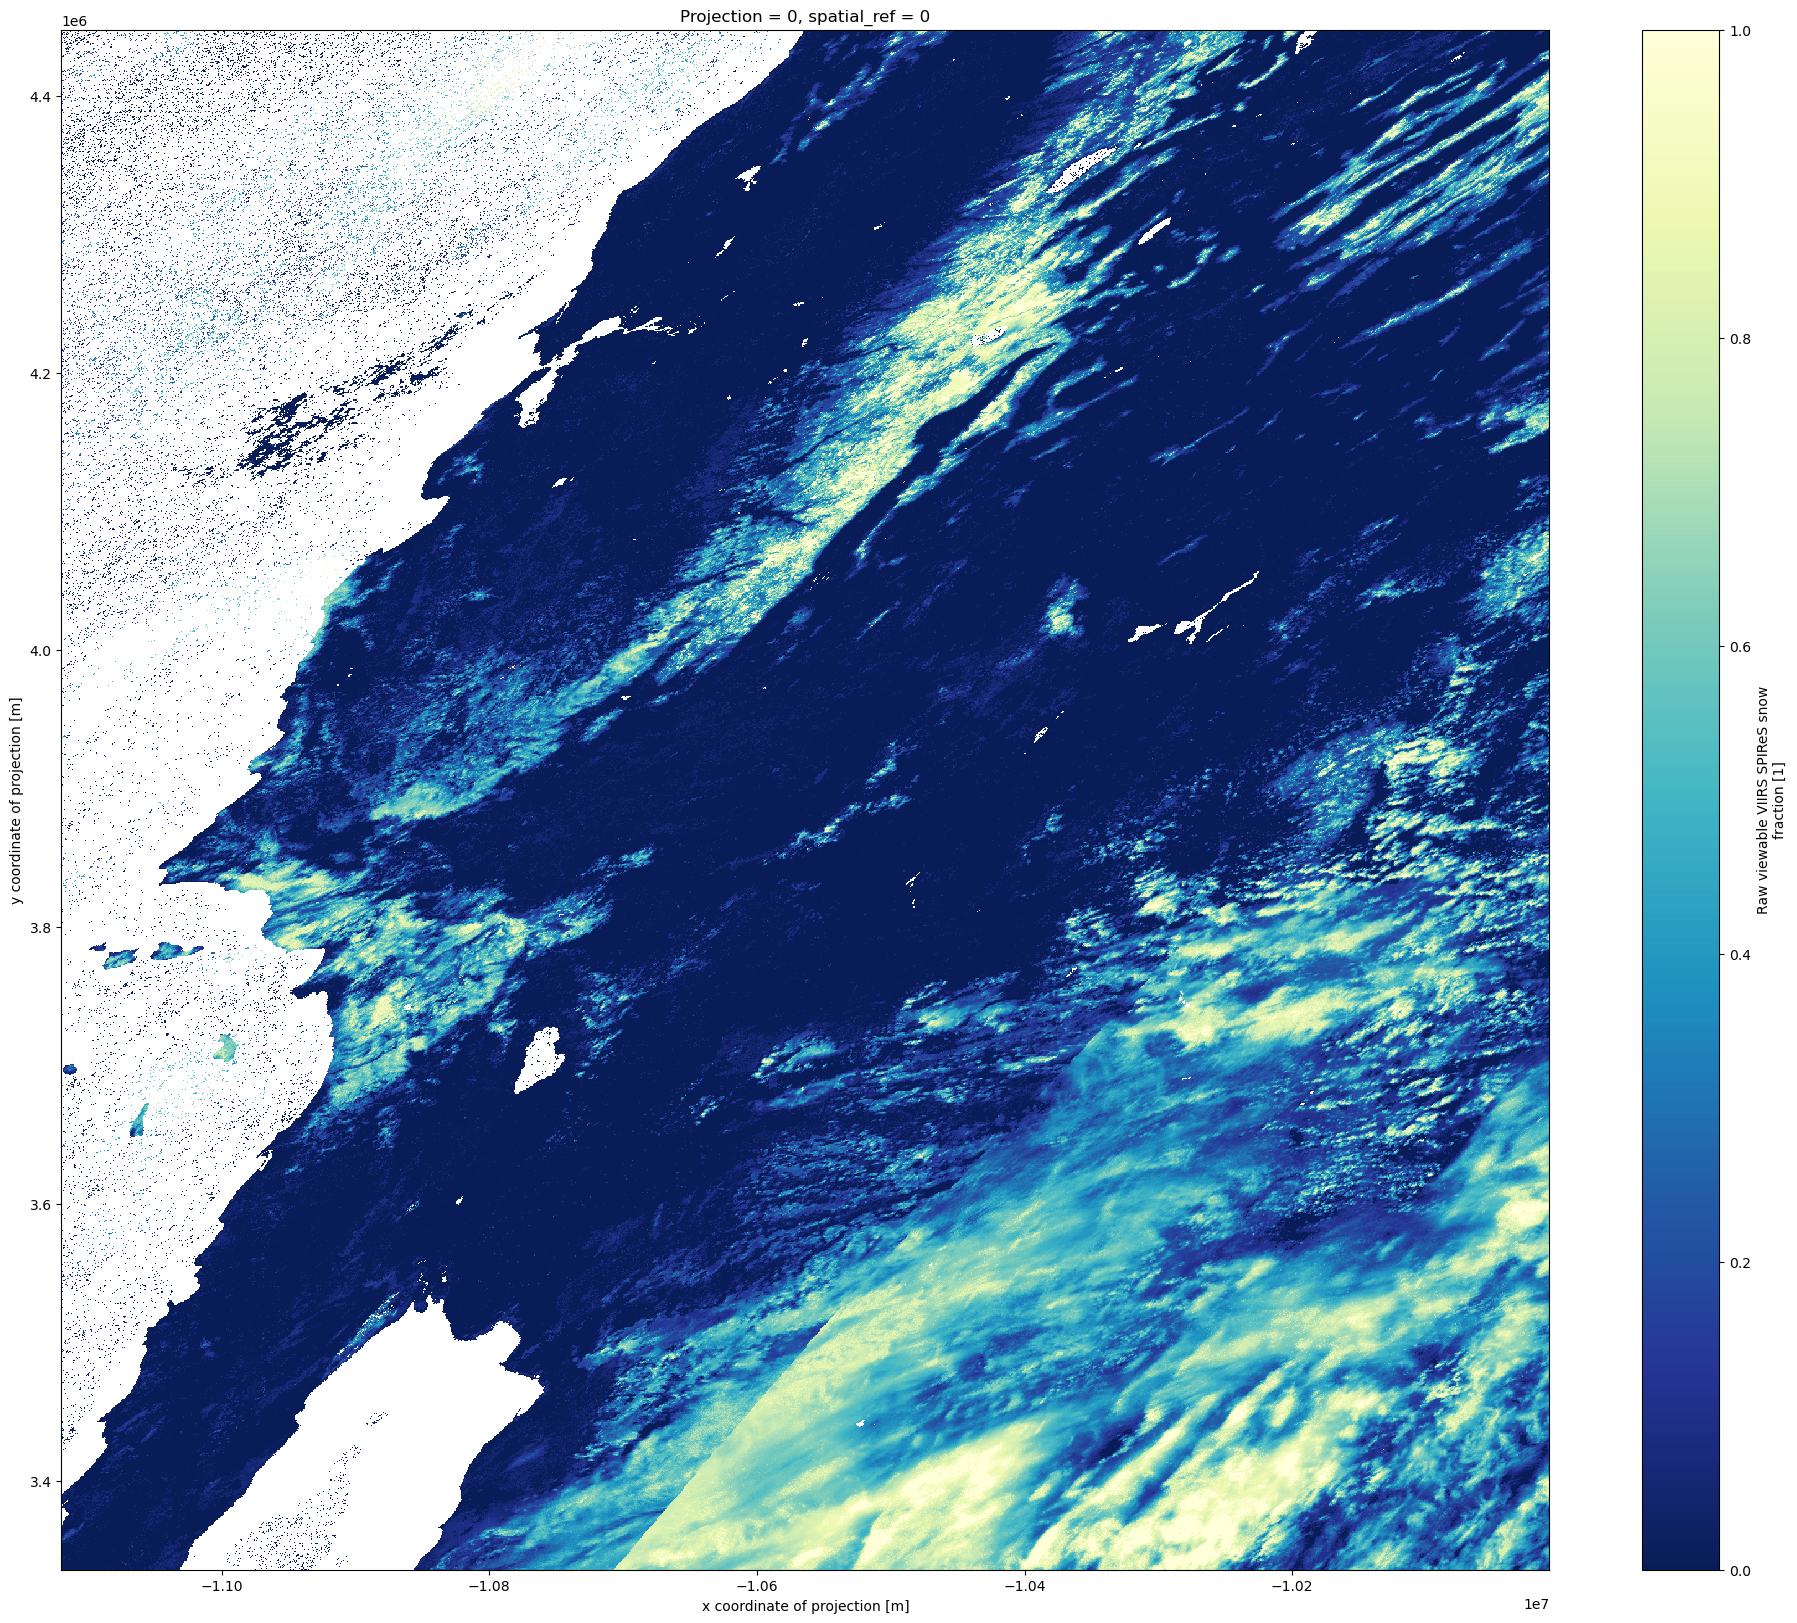

In [11]:
import xarray as xr

test = xr.open_dataset('/scratch/alpine/ropa5718/spipy/output/viirs/snpp/h08v05/2023-03-16/snpp_raw_output_h08v05_20230316.nc')
test['raw_viewable_snow_fraction'].plot(figsize=(24,20), cmap='YlGnBu_r')


In [10]:
test

<xarray.Dataset> Size: 144MB
Dimensions:                     (y: 2400, x: 2400, band: 7)
Coordinates:
  * y                           (y) float64 19kB 4.448e+06 ... 3.336e+06
  * x                           (x) float64 19kB -1.112e+07 ... -1.001e+07
  * band                        (band) <U3 84B 'I1' 'I2' 'I3' ... 'M8' 'M11'
    Projection                  int64 8B ...
    spatial_ref                 int64 8B ...
Data variables:
    raw_viewable_snow_fraction  (y, x) float32 23MB ...
    raw_shade_fraction          (y, x) float32 23MB ...
    dust_concentration          (y, x) float32 23MB ...
    grain_size                  (y, x) float32 23MB ...
    raw_canopy_fraction         (y, x) float32 23MB ...
    raw_snow_fraction           (y, x) float32 23MB ...
    valid_inversion_mask        (y, x) bool 6MB ...
Attributes: (12/38)
    projection:                                  HE5_GCTP_SNSOID
    proj_params:                                 [6371007.181       0.       ...
    sphere_code:                                 -1
    grid_origin:                                 HE5_HDFE_GD_UL
    x_resolution:                                463.31271652791725
    y_resolution:                                463.3127165279167
    ...                                          ...
    canopy_correction_applied:                   1
    canopy_vertical_to_horizontal_crown_radius:  2.7
    canopy_fraction_source:                      /gpfs/alpine1/scratch/ropa57...
    ice_fraction_applied:                        0
    execution_profile:                           cluster
    build_status:                                complete